# Anomaly Detection

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [3]:
# Loading the processed data
df = pd.read_parquet("../data/processed/prediction_anomaly_data.parquet")
df.head()

,tpep_pickup_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,...,payment_1,payment_2,payment_3,payment_4,ratecode_1.0,ratecode_2.0,ratecode_3.0,ratecode_4.0,ratecode_5.0,ratecode_6.0
0,2024-12-31 23:48:29,1.0,2.53,1.0,186,79,2,16.3,1.0,0.5,...,False,True,False,False,True,False,False,False,False,False
1,2024-12-31 23:52:40,1.0,6.72,1.0,114,151,1,34.5,1.0,0.5,...,True,False,False,False,True,False,False,False,False,False
2,2025-01-01 00:00:00,1.0,6.40,1.0,211,164,1,52.0,3.5,0.5,...,True,False,False,False,True,False,False,False,False,False
3,2025-01-01 00:00:19,1.0,10.08,1.0,132,61,1,44.3,1.0,0.5,...,True,False,False,False,True,False,False,False,False,False
4,2025-01-01 00:01:06,1.0,0.70,1.0,162,162,1,9.3,3.5,0.5,...,True,False,False,False,True,False,False,False,False,False


In [4]:
# Selecting Numeric Features for Anomaly Detection

anomaly_features = [
    'fare_amount', 'tip_amount', 'trip_distance', 
    'trip_duration_min', 'trip_speed_mph',
    'passenger_count', 'congestion_surcharge', 
    'cbd_congestion_fee', 'Airport_fee',
    'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge'
]

available_features = [f for f in anomaly_features if f in df.columns]

# feature matrix
X = df[available_features].copy()

In [5]:
# Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaled. Shape:", X_scaled.shape)

Data scaled. Shape: (3532447, 13)


In [6]:
# Isolation Forest Model
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,  # expect 1% anomalies
    random_state=42,
    verbose=1
)

In [7]:
#Fiting the model
iso_forest.fit(X_scaled)
print("Isolation Forest trained.")

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.8s


Isolation Forest trained.


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   11.8s finished


In [8]:
# Predicting anomalies
df['anomaly_pred'] = iso_forest.predict(X_scaled)

# Map: -1 = anomaly, 1 = normal
df['is_anomaly'] = (df['anomaly_pred'] == -1).astype(int)

print(f"Anomalies detected: {df['is_anomaly'].sum():,} ({df['is_anomaly'].mean()*100:.2f}%)")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.5s


Anomalies detected: 35,325 (1.00%)


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   11.6s finished


In [9]:
df['anomaly_score'] = iso_forest.score_samples(X_scaled)

# top 10 most anomalous trips
top_anomalies = df.nsmallest(10, 'anomaly_score')
print("Top 10 most anomalous trips:")
print(top_anomalies[['fare_amount', 'trip_distance', 'trip_duration_min', 'tip_amount', 'anomaly_score']])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.5s


Top 10 most anomalous trips:
         fare_amount  trip_distance  trip_duration_min  tip_amount  \
2012939        310.0          68.20          96.416667       30.00   
222191         185.0          59.60          81.733333       43.19   
2381260        265.0          78.35          82.416667       58.56   
1820406        355.1          51.15          69.233333       40.00   
316571         147.9          36.35         108.316667       34.53   
1969776        204.3          51.12          80.816667       45.46   
600822         311.7          64.34          81.683333       40.00   
3377677        397.1          64.23         145.700000       50.00   
3359201        187.8          51.04          76.400000       53.75   
12575          212.0          51.63          83.316667       47.06   

         anomaly_score  
2012939      -0.784885  
222191       -0.782234  
2381260      -0.781784  
1820406      -0.781705  
316571       -0.780648  
1969776      -0.780648  
600822       -0.779593  


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   11.6s finished


In [10]:
# Saving the model and scaler

joblib.dump(iso_forest, "../Models/isolation_forest_anomaly.pkl")
print(" Isolation Forest model saved to Models/isolation_forest_anomaly.pkl")
joblib.dump(scaler, "../Models/scaler_anomaly.pkl")
print(" Anomaly scaler saved")

 Isolation Forest model saved to Models/isolation_forest_anomaly.pkl
 Anomaly scaler saved


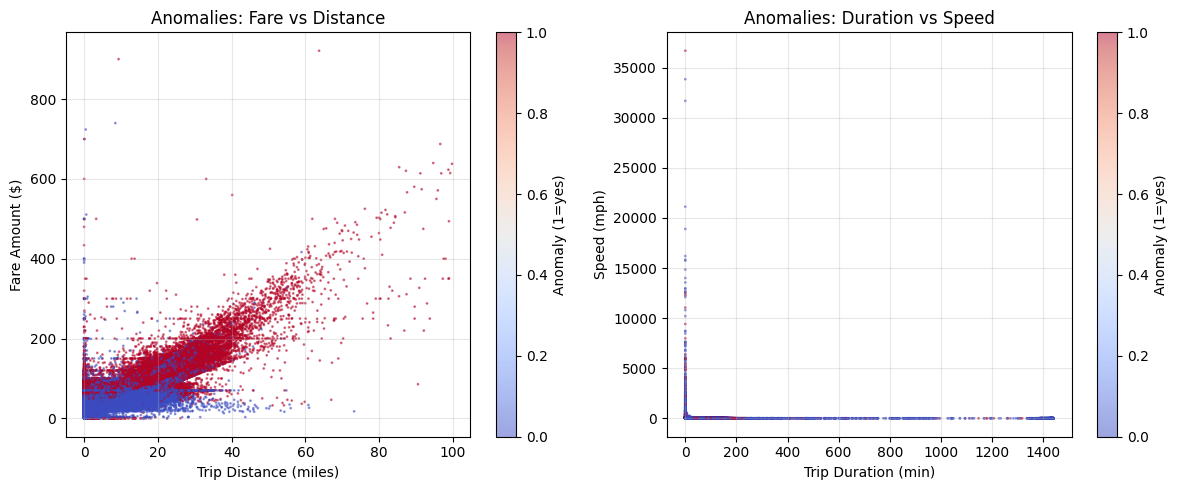

In [11]:
# Scatter plot: Fare vs Distance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['trip_distance'], df['fare_amount'], c=df['is_anomaly'], cmap='coolwarm', alpha=0.5, s=1)
plt.colorbar(label='Anomaly (1=yes)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.title('Anomalies: Fare vs Distance')
plt.grid(True, alpha=0.3)

# Scatter plot: Duration vs Speed
plt.subplot(1, 2, 2)
plt.scatter(df['trip_duration_min'], df['trip_speed_mph'], c=df['is_anomaly'], cmap='coolwarm', alpha=0.5, s=1)
plt.colorbar(label='Anomaly (1=yes)')
plt.xlabel('Trip Duration (min)')
plt.ylabel('Speed (mph)')
plt.title('Anomalies: Duration vs Speed')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
normal = df[df['is_anomaly'] == 0]
anomaly = df[df['is_anomaly'] == 1]

print("\n=== Comparison: Normal vs Anomaly Trips ===\n")
print(f"Normal trips count: {len(normal):,}")
print(f"Anomaly trips count: {len(anomaly):,}\n")

for col in available_features:
    print(f"{col}:")
    print(f"  Normal mean: {normal[col].mean():.2f}")
    print(f"  Anomaly mean: {anomaly[col].mean():.2f}")
    print()


=== Comparison: Normal vs Anomaly Trips ===

Normal trips count: 3,497,122
Anomaly trips count: 35,325

fare_amount:
  Normal mean: 18.92
  Anomaly mean: 99.10

tip_amount:
  Normal mean: 3.60
  Anomaly mean: 14.40

trip_distance:
  Normal mean: 3.28
  Anomaly mean: 17.12

trip_duration_min:
  Normal mean: 17.17
  Anomaly mean: 45.42

trip_speed_mph:
  Normal mean: 10.85
  Anomaly mean: 33.78

passenger_count:
  Normal mean: 1.29
  Anomaly mean: 1.95

congestion_surcharge:
  Normal mean: 2.30
  Anomaly mean: 0.36

cbd_congestion_fee:
  Normal mean: 0.56
  Anomaly mean: 0.35

Airport_fee:
  Normal mean: 0.15
  Anomaly mean: 0.79

extra:
  Normal mean: 1.61
  Anomaly mean: 1.55

mta_tax:
  Normal mean: 0.50
  Anomaly mean: 0.12

tolls_amount:
  Normal mean: 0.50
  Anomaly mean: 9.35

improvement_surcharge:
  Normal mean: 0.98
  Anomaly mean: 0.98



## Anomaly Detection Summary 

We used a machine learning model called **Isolation Forest** to find unusual taxi trips in our dataset. The model looks at features like fare, distance, duration, speed, tips, and surcharges, and flags trips that are very different from the typical pattern.

**What did we find?**  
Out of 3.5 million trips, the model flagged about **35,000 trips (1%)** as unusual.

**What makes a trip “unusual”?**  
Compared to normal trips, the flagged trips are very different:

- **Fare:** Normal trips average $19; unusual trips average **$99** (more than 5× higher).
- **Distance:** Normal trips average 3.3 miles; unusual trips average **17 miles**.
- **Speed:** Normal trips average 11 mph (typical city traffic); unusual trips average **34 mph** (much faster, like highway driving).
- **Tolls:** Normal trips have low tolls ($0.50); unusual trips average **$9.35** (longer routes with toll roads).
- **Airport fee:** Unusual trips have much higher airport fees ($0.79 vs $0.15), confirming many are airport trips.

**What causes these anomalies?**  
The majority of unusual trips appear to be **long‑distance airport trips** (JFK, Newark, LaGuardia) or trips to/from outer boroughs and suburbs. These naturally have higher fares, longer distances, higher speeds, and tolls. A small fraction are likely **data errors** (e.g., extremely high fare for very short distance), but the model mainly identified legitimate but rare trip types.

**Why is this useful?**  
- **For operations:** The taxi company can monitor unusual trips to detect potential meter tampering or billing errors.
- **For data quality:** We can review the most extreme anomalies (top 10) to find and correct data entry mistakes.
- **For pricing:** Understanding that 1% of trips are high‑value airport runs helps tailor driver incentives and surge pricing.

**What’s next?**  
We will keep the anomaly flag in our dataset. For fare prediction models, we may remove the most obvious data‑error anomalies (e.g., $959 for 0.04 miles) to improve accuracy. For real‑time monitoring, we can set up alerts when a trip’s anomaly score exceeds a threshold.